In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *


In [2]:
data_collection = {}
for prefix, name in zip(['20230526', '20230623'], ['Old', 'New']):
    data_collection[name] = read_extract_sims_ts(prefix)

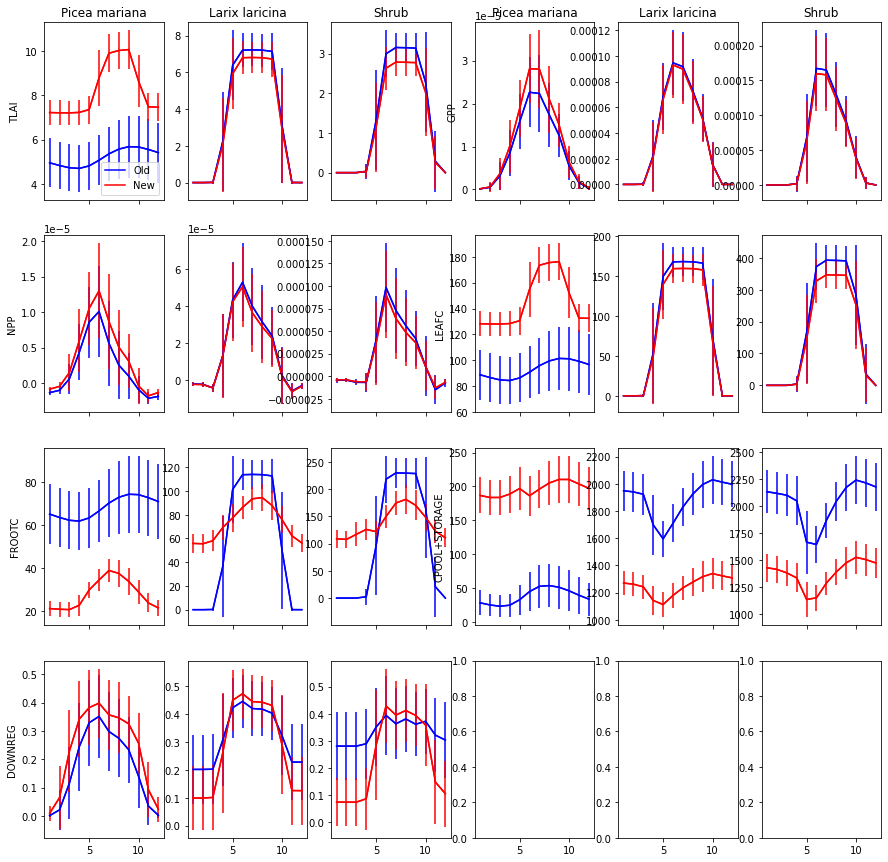

In [7]:
var_list = ['TLAI', 'GPP', 'NPP', 'LEAFC', 'FROOTC', 'CPOOL+STORAGE', 'DOWNREG'] #'LEAFC_ALLOC', 'FROOTC_ALLOC', 'CPOOL_TO_LEAFC_STORAGE', 'CPOOL_TO_FROOTC_STORAGE']
pft_list = [2, 3, 11]
pft_names = ['Picea mariana', 'Larix laricina', 'Shrub']

fig, axes = plt.subplots(int(np.ceil(len(var_list) / 2)), len(pft_list) * 2,
                             figsize = (15, 15), sharex = True)

for i, var in enumerate(var_list):
    for j, (pft, pft_name) in enumerate(zip(pft_list, pft_names)):
        ax = axes[int(np.floor(i/2)), j + len(pft_list) * np.mod(i, 2)]

        for name, color in zip(['Old', 'New'], ['b', 'r']):

            temp0 = data_collection[name]

            if var == 'CPOOL+STORAGE':
                temp = temp0.loc[:, (slice(None), 'TOTVEGC', pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), 'TOTVEGC', pft, 'hollow')].values * 0.36
                for v2 in ['LEAFC', 'LIVESTEMC', 'DEADSTEMC', 'FROOTC', 'LIVECROOTC', 'DEADCROOTC', 
                           'LEAFC_XFER', 'LIVESTEMC_XFER', 'DEADSTEMC_XFER', 'FROOTC_XFER',
                           'LIVECROOTC_XFER', 'DEADCROOTC_XFER', 'GRESP_XFER']:
                    temp2 = temp0.loc[:, (slice(None), v2, pft, 'hummock')] * 0.64 + \
                            temp0.loc[:, (slice(None), v2, pft, 'hollow')].values * 0.36
                    temp = temp - temp2.values
            else:
                temp = temp0.loc[:, (slice(None), var, pft, 'hummock')] * 0.64 + \
                    temp0.loc[:, (slice(None), var, pft, 'hollow')].values * 0.36

            temp_mean = temp.groupby(temp.index.month).mean().mean(axis = 1)
            temp_std = temp.groupby(temp.index.month).apply(lambda x: x.values.reshape(-1).std())

            ## normalize to annual average = 1
            #temp_std = temp_std / temp_mean.mean()
            #temp_mean = temp_mean / temp_mean.mean()

            ax.plot(range(1, 13), temp_mean, '-', color = color, label = name)
            ax.errorbar(range(1, 13), temp_mean, yerr = temp_std, ls = '-', color = color)

        if i < 2:
            ax.set_title(pft_name)
        if j == 0:
            ax.set_ylabel(var)
            if i == 0:
                ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality.png'), 
            dpi = 600., bbox_inches = 'tight')

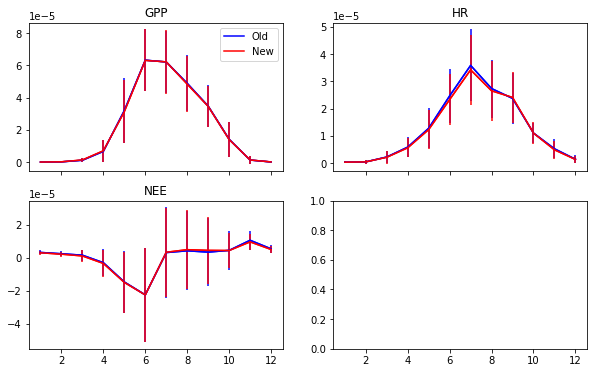

In [11]:
#var_list = ['TSOI_3', 'SWC_1', 'HR', 'NEE', 'NET_NMIN', 'BTRAN']
var_list = ['GPP', 'HR', 'NEE']

#fig, axes = plt.subplots(2, 3, figsize = (10, 6), sharex = True)
fig, axes = plt.subplots(2, 2, figsize = (10, 6), sharex = True)

for i, var in enumerate(var_list):
    ax = axes.flat[i]

    for name, color in zip(['Old', 'New'], ['b', 'r']):

        temp0 = data_collection[name]

        if var == 'GPP':
            temp = {}
            for pft in [2, 3, 11]:
                temp[pft] = temp0.loc[:, (slice(None), var, pft, 'hummock')] * 0.64 + \
                            temp0.loc[:, (slice(None), var, pft, 'hollow')].values * 0.36
            temp = temp[2] * 0.36 + temp[3].values * 0.14 + temp[11].values * 0.25
        else:
            temp = temp0.loc[:, (slice(None), var, 0, 'hummock')] * 0.64 + \
                temp0.loc[:, (slice(None), var, 0, 'hollow')].values * 0.36

        temp_mean = temp.groupby(temp.index.month).mean().mean(axis = 1)
        temp_std = temp.groupby(temp.index.month).apply(lambda x: x.values.reshape(-1).std())

        ## normalize to annual average = 1
        #temp_std = temp_std / temp_mean.mean()
        #temp_mean = temp_mean / temp_mean.mean()

        ax.plot(range(1, 13), temp_mean, '-', color = color, label = name)
        ax.errorbar(range(1, 13), temp_mean, yerr = temp_std, ls = '-', color = color)

    ax.set_title(var)
    if i == 0:
        ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality2.png'), 
            dpi = 600., bbox_inches = 'tight')